# 07 — EXP_08 + EXP_09: Confidence-Aware Rejection

**The thesis-central novelty.** Given the per-question signal vector assembled from Phases 4 + 6, can a simple threshold-based rejection layer identify wrong answers and improve the accuracy of accepted answers?

## Setup

- **Surface**: Multi-Hop on `golden_234` — the surface where RAGAS metrics live (Faithfulness, Context Precision, Context Recall, Answer Relevancy). Multi-Hop has the only graded Faithfulness distribution (median 0.25) among the architectures, so the confidence layer has signal to work with.
- **Confidence vector** (8 normalised features in [0, 1]):
  - 4 **retrieval-quality** features from `retrieval.jsonl`: `retrieval_score_{mean,max,var}`, `n_chunks`
  - 4 **RAGAS** features from `ragas_scores.csv`: `faithfulness`, `context_precision`, `context_recall`, `answer_relevancy`
  - **Excluded**: `answer_correctness` — quasi-circular for this task (it's the LLM-judge's overall correctness, which we'd be using to predict gold correctness)
- **Confidence score**: equal-weighted mean of normalised signals → [0, 1]
- **Threshold sweep**: τ ∈ {0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9}
- **Cost**: $0 (pure aggregation over existing data)

## What we compare

Four configurations of the confidence vector, all on the same 234 questions:

1. **Combined** (8 signals, equal weights) — the headline configuration.
2. **RAGAS-only** (4 RAGAS signals) — strips retrieval features; how much do they add?
3. **Faithfulness-only** — the simplest possible single-signal baseline (the central thesis grounding signal).
4. **Retrieval-only** (4 retrieval signals) — control: do retrieval scores alone predict correctness?

## 1. Setup

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.confidence.signals import (
    SignalArtefacts, build_signal_table, combine_signals,
    DEFAULT_SIGNAL_COLUMNS, RAGAS_SIGNALS, RETRIEVAL_SIGNALS,
)
from src.confidence.rejection import (
    sweep_thresholds, baseline_no_rejection, DEFAULT_THRESHOLDS,
)

ARCH_RUN = "exp_05_multi_hop_rag__golden_234"
print("Surface:", ARCH_RUN)

Surface: exp_05_multi_hop_rag__golden_234


## 2. EXP_08 — Build the per-question signal table

In [2]:
art = SignalArtefacts.for_run(REPO_ROOT / "results", ARCH_RUN)
df = build_signal_table(art, normalise=True)

baseline_acc = df.is_correct.mean()
print(f"Loaded {len(df)} questions; baseline accuracy = {baseline_acc:.4f}")
print("\nNon-null counts per signal column:")
for c in DEFAULT_SIGNAL_COLUMNS:
    print(f"  {c}: {df[c].notna().sum()}/{len(df)}")

# Persist the table for Phase 8 use
OUT_DIR = REPO_ROOT / "results" / "exp_08_confidence_signals"
OUT_DIR.mkdir(parents=True, exist_ok=True)
df.to_parquet(OUT_DIR / f"{ARCH_RUN}__signals.parquet", index=False)
print(f"\n✓ Wrote {OUT_DIR / f'{ARCH_RUN}__signals.parquet'}")

Loaded 234 questions; baseline accuracy = 0.9017

Non-null counts per signal column:
  retrieval_score_mean: 234/234
  retrieval_score_max: 234/234
  retrieval_score_var: 234/234
  n_chunks: 234/234
  faithfulness: 232/234
  context_precision: 225/234
  context_recall: 234/234
  answer_relevancy: 232/234

✓ Wrote /Users/rajak/Workstation/Projects/myGitHub/thesis-project/results/exp_08_confidence_signals/exp_05_multi_hop_rag__golden_234__signals.parquet


## 3. Signal distributions — correct vs wrong rows

Does each signal discriminate correct from wrong questions? A signal is useful for rejection if its mean on correct rows is *higher* than on wrong rows.

In [3]:
diag_rows = []
for c in DEFAULT_SIGNAL_COLUMNS:
    raw_col = f"{c}_raw"
    if raw_col not in df.columns:
        continue
    mean_correct = df.loc[df.is_correct, raw_col].mean()
    mean_wrong = df.loc[~df.is_correct, raw_col].mean()
    gap = mean_correct - mean_wrong
    diag_rows.append({
        "signal": c,
        "mean_correct_raw": mean_correct,
        "mean_wrong_raw": mean_wrong,
        "gap": gap,
    })
diag = pd.DataFrame(diag_rows).sort_values("gap", ascending=False)
print("=== Signal discrimination — correct vs wrong rows ===")
print(diag.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print("\nReading: positive gap means the signal is higher on correct rows → useful for accept-if-high rejection rule.")

=== Signal discrimination — correct vs wrong rows ===
              signal  mean_correct_raw  mean_wrong_raw    gap
      context_recall            0.7607          0.2609 0.4998
            n_chunks           11.6303         11.2174 0.4129
   context_precision            0.3987          0.1430 0.2557
        faithfulness            0.3078          0.0606 0.2473
    answer_relevancy            0.6006          0.5491 0.0514
 retrieval_score_max            0.7771          0.7676 0.0095
retrieval_score_mean            0.7383          0.7374 0.0009
 retrieval_score_var            0.0006          0.0004 0.0002

Reading: positive gap means the signal is higher on correct rows → useful for accept-if-high rejection rule.


## 4. EXP_09 — Threshold sweep across four signal configurations

Each configuration produces a confidence score in [0, 1] for every question. Sweep τ ∈ {0.3, …, 0.9}: at each threshold, accept questions with confidence ≥ τ and report accuracy on accepted, rejection rate, and the corresponding uplift over the baseline.

In [4]:
configs = {
    "combined":     combine_signals(df),  # all 8 signals, equal weights
    "RAGAS_only":   combine_signals(df, signal_columns=RAGAS_SIGNALS),
    "faithfulness_only": df["faithfulness"],
    "retrieval_only":    combine_signals(df, signal_columns=RETRIEVAL_SIGNALS),
}

print(f"=== Baseline (no rejection) ===")
print(pd.Series(baseline_no_rejection(df.is_correct)).to_string())

all_sweeps = {}
for name, conf in configs.items():
    sweep = sweep_thresholds(conf, df.is_correct)
    sweep["config"] = name
    all_sweeps[name] = sweep
    print(f"\n=== {name} ===")
    print(sweep.drop(columns=["config"]).to_string(index=False, float_format=lambda v: f'{v:.4f}' if isinstance(v, float) else str(v)))

# Persist sweep results
REJ_DIR = REPO_ROOT / "results" / "exp_09_confidence_rejection"
REJ_DIR.mkdir(parents=True, exist_ok=True)
combined = pd.concat(all_sweeps.values(), ignore_index=True)
combined.to_csv(REJ_DIR / f"{ARCH_RUN}__threshold_sweeps.csv", index=False)
print(f"\n✓ Wrote {REJ_DIR / f'{ARCH_RUN}__threshold_sweeps.csv'}")

=== Baseline (no rejection) ===
threshold                         -inf
n_total                     234.000000
n_accepted                  234.000000
n_rejected                    0.000000
rejection_rate                0.000000
accuracy_on_accepted          0.901709
accuracy_uplift               0.000000
recall_of_correct             1.000000
recall_of_wrong_rejected      0.000000

=== combined ===
 threshold  n_total  n_accepted  n_rejected  rejection_rate  accuracy_on_accepted  accuracy_uplift  recall_of_correct  recall_of_wrong_rejected
    0.3000      234         206          28          0.1197                0.9272           0.0255             0.9052                    0.3478
    0.4000      234         174          60          0.2564                0.9598           0.0581             0.7915                    0.6957
    0.5000      234         121         113          0.4829                0.9669           0.0652             0.5545                    0.8261
    0.6000      234    

## 5. Pareto plot — accuracy-on-accepted vs rejection-rate

The standard view for confidence-aware rejection. Higher curve = better (less rejection for the same accuracy). Each curve is one signal configuration; each point is one τ.

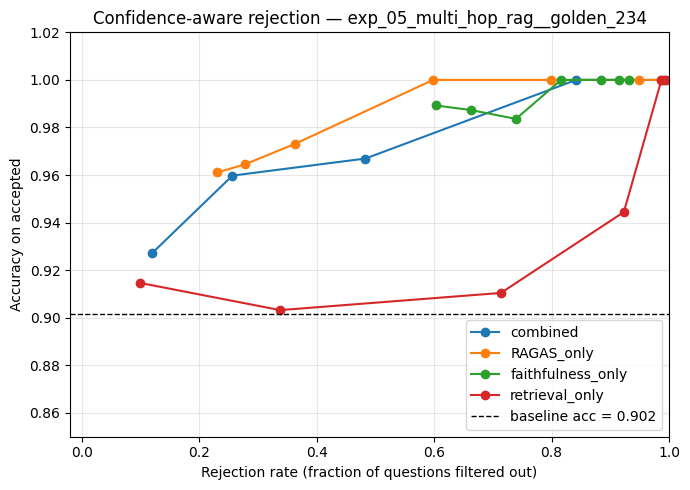

✓ Saved /Users/rajak/Workstation/Projects/myGitHub/thesis-project/results/exp_09_confidence_rejection/exp_05_multi_hop_rag__golden_234__pareto.png


In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, sweep in all_sweeps.items():
    ax.plot(sweep["rejection_rate"], sweep["accuracy_on_accepted"], marker="o", label=name)
ax.axhline(baseline_acc, color="k", ls="--", lw=1, label=f"baseline acc = {baseline_acc:.3f}")
ax.set_xlabel("Rejection rate (fraction of questions filtered out)")
ax.set_ylabel("Accuracy on accepted")
ax.set_title(f"Confidence-aware rejection — {ARCH_RUN}")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
ax.set_xlim(-0.02, 1.0)
ax.set_ylim(0.85, 1.02)
plt.tight_layout()
plt.savefig(REJ_DIR / f"{ARCH_RUN}__pareto.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"✓ Saved {REJ_DIR / f'{ARCH_RUN}__pareto.png'}")

## 6. Best operating points

Two useful ways to pick the "best" τ:

1. **Max accuracy at ≤ 30 % rejection** — keep most of the population, hit the highest accuracy you can while doing it.
2. **Max accuracy at ≤ 50 % rejection** — accept more aggressive rejection for higher accuracy.

Plus the **perfection point**: smallest τ that produces 100 % accuracy on accepted.

In [6]:
def _pick(sweep_df, max_rej):
    sub = sweep_df[sweep_df.rejection_rate <= max_rej].copy()
    if sub.empty:
        return None
    # max accuracy_on_accepted, tie-break by smallest rejection_rate
    sub = sub.sort_values(["accuracy_on_accepted", "rejection_rate"], ascending=[False, True])
    return sub.iloc[0].to_dict()

def _pick_perfect(sweep_df):
    sub = sweep_df[sweep_df.accuracy_on_accepted >= 1.0 - 1e-9]
    if sub.empty:
        return None
    return sub.sort_values("rejection_rate").iloc[0].to_dict()

print("=== Best operating points per configuration ===\n")
for name, sweep in all_sweeps.items():
    print(f"--- {name} ---")
    for label, max_rej in [("≤30% rejection", 0.30), ("≤50% rejection", 0.50)]:
        p = _pick(sweep, max_rej)
        if p:
            print(f"  {label}: τ={p['threshold']:.2f}  acc={p['accuracy_on_accepted']:.4f}  reject={p['rejection_rate']:.3f}  uplift={p['accuracy_uplift']:+.4f}")
    p = _pick_perfect(sweep)
    if p:
        print(f"  100% accuracy:  τ={p['threshold']:.2f}  reject={p['rejection_rate']:.3f}  recall_of_correct={p['recall_of_correct']:.3f}")
    print()

=== Best operating points per configuration ===

--- combined ---
  ≤30% rejection: τ=0.40  acc=0.9598  reject=0.256  uplift=+0.0581
  ≤50% rejection: τ=0.50  acc=0.9669  reject=0.483  uplift=+0.0652
  100% accuracy:  τ=0.60  reject=0.842  recall_of_correct=0.175

--- RAGAS_only ---
  ≤30% rejection: τ=0.40  acc=0.9645  reject=0.278  uplift=+0.0628
  ≤50% rejection: τ=0.50  acc=0.9732  reject=0.363  uplift=+0.0714
  100% accuracy:  τ=0.60  reject=0.598  recall_of_correct=0.445

--- faithfulness_only ---
  100% accuracy:  τ=0.60  reject=0.816  recall_of_correct=0.204

--- retrieval_only ---
  ≤30% rejection: τ=0.30  acc=0.9147  reject=0.098  uplift=+0.0130
  ≤50% rejection: τ=0.30  acc=0.9147  reject=0.098  uplift=+0.0130
  100% accuracy:  τ=0.70  reject=0.987  recall_of_correct=0.014



## 7. Headline summary

In [7]:
print("=== EXP_09 headline (Multi-Hop golden_234) ===\n")
print(f"Baseline (no rejection): accuracy {baseline_acc:.4f} on {len(df)} questions")

best_combined_30 = _pick(all_sweeps["combined"], 0.30)
best_combined_50 = _pick(all_sweeps["combined"], 0.50)
best_combined_100 = _pick_perfect(all_sweeps["combined"])

if best_combined_30:
    print(f"\nCombined confidence (8 signals, equal weights):")
    print(f"  ≤30% rejection: τ={best_combined_30['threshold']:.2f}  "
          f"accuracy={best_combined_30['accuracy_on_accepted']:.4f} (+{best_combined_30['accuracy_uplift']*100:.2f} pp), "
          f"keeps {best_combined_30['n_accepted']}/{len(df)} questions")
if best_combined_50:
    print(f"  ≤50% rejection: τ={best_combined_50['threshold']:.2f}  "
          f"accuracy={best_combined_50['accuracy_on_accepted']:.4f} (+{best_combined_50['accuracy_uplift']*100:.2f} pp), "
          f"keeps {best_combined_50['n_accepted']}/{len(df)}")
if best_combined_100:
    print(f"  perfect accuracy: τ={best_combined_100['threshold']:.2f}  "
          f"reject={best_combined_100['rejection_rate']*100:.1f}%, "
          f"recall of correct={best_combined_100['recall_of_correct']*100:.1f}%")

# Compare combined vs RAGAS-only at the same operating point
best_ragas_30 = _pick(all_sweeps["RAGAS_only"], 0.30)
if best_combined_30 and best_ragas_30:
    print(f"\nRAGAS-only at ≤30%:  acc={best_ragas_30['accuracy_on_accepted']:.4f} (+{best_ragas_30['accuracy_uplift']*100:.2f} pp)")
    print(f"  → adding retrieval signals: {(best_combined_30['accuracy_on_accepted'] - best_ragas_30['accuracy_on_accepted'])*100:+.2f} pp")

=== EXP_09 headline (Multi-Hop golden_234) ===

Baseline (no rejection): accuracy 0.9017 on 234 questions

Combined confidence (8 signals, equal weights):
  ≤30% rejection: τ=0.40  accuracy=0.9598 (+5.81 pp), keeps 174/234 questions
  ≤50% rejection: τ=0.50  accuracy=0.9669 (+6.52 pp), keeps 121/234
  perfect accuracy: τ=0.60  reject=84.2%, recall of correct=17.5%

RAGAS-only at ≤30%:  acc=0.9645 (+6.28 pp)
  → adding retrieval signals: -0.47 pp


---

**Next.** Phase 8 — hallucination taxonomy (EXP_13 / 14 / 15). Classify the rejected questions into 6 error categories (unsupported_diagnosis, unsupported_treatment, wrong_reasoning_chain, partial_evidence_misuse, option_mismatch, context_omission). Cost: ~$3 GPT-4o-mini classifier-assisted.